# HW14 – Эмбеддинги, FAISS, оценка retrieval и mini-RAG

**База знаний**: COVID-19 FAQ (30 документов)

В этом ноутбуке:
- Загружаем базу знаний (COVID-19 FAQ)
- Реализуем чанкинг документов
- Строим эмбеддинги и индекс FAISS
- Оцениваем качество retrieval
- Выполняем эксперимент с параметрами
- Обновляем базу знаний и переиндексируем
- Собираем mini-RAG конвейер
- Анализируем ошибки

## 1. Импорты, seed и среда

In [ ]:
import os
import sys
import random
import subprocess
import json
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            return True
        except Exception as e:
            print(f"Не удалось установить {package_name}: {e!r}")
            return False


FAISS_OK = ensure_package("faiss-cpu", "faiss")
ST_OK = ensure_package("sentence-transformers", "sentence_transformers")

try:
    import faiss
    FAISS_AVAILABLE = True
except Exception:
    FAISS_AVAILABLE = False
    print("FAISS недоступен, будет fallback на sklearn")

print(f"FAISS доступен: {FAISS_AVAILABLE}")
print(f"sentence-transformers доступен: {ST_OK}")

FAISS доступен: True
sentence-transformers доступен: True


In [2]:
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
    except Exception:
        pass

set_seed(SEED)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print(f"Seed: {SEED}")
print(f"Устройство: {DEVICE}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

Seed: 42
Устройство: cuda
NumPy: 1.26.4
Pandas: 2.2.3


## 2. База знаний и первичный анализ

In [3]:
data_path = os.path.join("data", "COVID19_FAQ.csv")
df = pd.read_csv(data_path)

print(f"Всего документов в базе: {len(df)}")
print(f"Колонки: {list(df.columns)}")
display(df.head())

Всего документов в базе: 30
Колонки: ['questions', 'answers']


,questions,answers
0,1. How does COVID-19 spread?,People can catch COVID-19 from others who have...
1,2. What are the symptoms of COVID-19?,The most common symptoms of COVID-19 are fever...
2,3. How do I know if it is COVID-19 or just the...,A COVID-19 infection has the same signs and sy...
3,4. Can the virus that causes COVID-19 be trans...,Studies to date suggest that the virus that ca...
4,5. What can I do to protect myself and prevent...,Protection measures for everyone. Stay aware o...


In [4]:
documents = []
for idx, row in df.iterrows():
    question = str(row["questions"]).strip()
    answer = str(row["answers"]).strip()
    doc_id = f"covid_faq_{idx:03d}"
    text = f"Question: {question}\nAnswer: {answer}"
    documents.append({
        "doc_id": doc_id,
        "question": question,
        "answer": answer,
        "text": text,
    })

print(f"Всего документов: {len(documents)}")

Всего документов: 30


In [5]:
for i in [0, 5, 10, 15, 20]:
    doc = documents[i]
    print(f"\n--- Документ {i+1}: {doc['doc_id']} ---")
    print(f"Вопрос: {doc['question'][:100]}...")
    print(f"Ответ: {doc['answer'][:150]}...")


--- Документ 1: covid_faq_000 ---
Вопрос: 1. How does COVID-19 spread?...
Ответ: People can catch COVID-19 from others who have the virus. The disease can spread from person to person through small droplets from the nose or mouth w...

--- Документ 6: covid_faq_005 ---
Вопрос: 6. I am well and asymptomatic. Should I use a mask?...
Ответ: According to the WHO, for individuals without respiratory symptoms, a medical mask is not required, as no evidence is available on its usefulness to p...

--- Документ 11: covid_faq_010 ---
Вопрос: 11. Should I worry about COVID-19?...
Ответ: Illness due to COVID-19 infection is generally mild, especially for children and young adults. However, it can cause serious illness: about 1 in every...

--- Документ 16: covid_faq_015 ---
Вопрос: 16. Should I wear a mask to protect myself from catching the COVID-19 virus?...
Ответ: Only wear a mask if you are ill with COVID-19 symptoms (especially coughing) or looking after someone who may have COVID-19. Dispos

## 3. Чанкинг документов

In [7]:
def chunk_text(text: str, chunk_size: int = 50, overlap: int = 10) -> List[str]:
    """Разбиение текста на чанки по словам с overlap."""
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")
    
    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


CHUNK_SIZE = 50
OVERLAP = 10

print(f"Параметры чанкинга: chunk_size={CHUNK_SIZE}, overlap={OVERLAP}")
print(f"Шаг (step) = {CHUNK_SIZE - OVERLAP} слов")

Параметры чанкинга: chunk_size=50, overlap=10
Шаг (step) = 40 слов


In [8]:
all_chunks = []
for doc in documents:
    chunks = chunk_text(doc["text"], chunk_size=CHUNK_SIZE, overlap=OVERLAP)
    for chunk_id, chunk_text_value in enumerate(chunks, start=1):
        all_chunks.append({
            "doc_id": doc["doc_id"],
            "question": doc["question"],
            "chunk_id": f'{doc["doc_id"]}_chunk_{chunk_id:02d}',
            "chunk_text": chunk_text_value,
        })

chunks_df = pd.DataFrame(all_chunks)
print(f"Всего чанков: {len(chunks_df)}")
print(f"Уникальных документов: {chunks_df['doc_id'].nunique()}")

chunks_per_doc = chunks_df.groupby("doc_id").size()
print(f"\nЧанков на документ: min={chunks_per_doc.min()}, max={chunks_per_doc.max()}, mean={chunks_per_doc.mean():.1f}")
display(chunks_df.head(3))

Всего чанков: 60
Уникальных документов: 30

Чанков на документ: min=1, max=4, mean=2.0


,doc_id,question,chunk_id,chunk_text
0,covid_faq_000,1. How does COVID-19 spread?,covid_faq_000_chunk_01,Question: 1. How does COVID-19 spread? Answer:...
1,covid_faq_000,1. How does COVID-19 spread?,covid_faq_000_chunk_02,COVID-19 coughs or exhales. These droplets lan...
2,covid_faq_000,1. How does COVID-19 spread?,covid_faq_000_chunk_03,in droplets from a person with COVID-19 who co...


In [9]:
sample_doc = documents[0]
sample_chunks = chunk_text(sample_doc["text"], chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"Документ: {sample_doc['doc_id']}")
print(f"Вопрос: {sample_doc['question']}")
print(f"Число чанков: {len(sample_chunks)}")
print(f"\n--- Первый чанк ---")
print(sample_chunks[0][:300])
if len(sample_chunks) > 1:
    print(f"\n--- Второй чанк ---")
    print(sample_chunks[1][:300])

Документ: covid_faq_000
Вопрос: 1. How does COVID-19 spread?
Число чанков: 3

--- Первый чанк ---
Question: 1. How does COVID-19 spread? Answer: People can catch COVID-19 from others who have the virus. The disease can spread from person to person through small droplets from the nose or mouth which are spread when a person with COVID-19 coughs or exhales. These droplets land on objects and

--- Второй чанк ---
COVID-19 coughs or exhales. These droplets land on objects and surfaces around the person. Other people then catch COVID-19 by touching these objects or surfaces, then touching their eyes, nose or mouth. People can also catch COVID-19 if they breathe in droplets from a person with COVID-19 who cough


## 4. Эмбеддинги и индекс FAISS

In [10]:
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

if ST_OK:
    try:
        from sentence_transformers import SentenceTransformer
        embedder = SentenceTransformer(MODEL_NAME, device=DEVICE)
        BACKEND_NAME = f"SentenceTransformer: {MODEL_NAME}"
        print(f"Загружена модель: {MODEL_NAME}")
        print(f"Устройство: {DEVICE}")
    except Exception as e:
        print(f"Не удалось загрузить SentenceTransformer: {e}")
        print("Переключаемся на TF-IDF fallback")
        embedder = TfidfVectorizer(ngram_range=(1, 2))
        BACKEND_NAME = "TF-IDF (fallback)"
else:
    embedder = TfidfVectorizer(ngram_range=(1, 2))
    BACKEND_NAME = "TF-IDF (fallback)"

print(f"Используемый backend: {BACKEND_NAME}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Загружена модель: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Устройство: cuda
Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [11]:
chunk_texts = chunks_df["chunk_text"].tolist()

if BACKEND_NAME.startswith("SentenceTransformer"):
    chunk_vectors = embedder.encode(
        chunk_texts,
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype(np.float32)
else:
    tfidf_matrix = embedder.fit_transform(chunk_texts)
    chunk_vectors = tfidf_matrix.toarray().astype(np.float32)
    norms = np.linalg.norm(chunk_vectors, axis=1, keepdims=True) + 1e-12
    chunk_vectors = chunk_vectors / norms

print(f"Форма векторов чанков: {chunk_vectors.shape}")
print(f"Размерность эмбеддинга: {chunk_vectors.shape[1]}")

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Форма векторов чанков: (60, 384)
Размерность эмбеддинга: 384


In [12]:
dimension = chunk_vectors.shape[1]

if FAISS_AVAILABLE:
    index = faiss.IndexFlatIP(dimension)
    index.add(chunk_vectors)
    print(f"FAISS индекс создан: {index.ntotal} векторов, размерность {dimension}")
else:
    nn = NearestNeighbors(n_neighbors=5, metric="cosine")
    nn.fit(chunk_vectors)
    index = nn
    print(f"Sklearn NearestNeighbors создан: {len(chunk_vectors)} векторов")

FAISS индекс создан: 60 векторов, размерность 384


In [13]:
def search_with_index(query, idx, chunks_dataframe, top_k=5):
    """Поиск с FAISS или sklearn индексом."""
    if BACKEND_NAME.startswith("SentenceTransformer"):
        qv = embedder.encode([query], normalize_embeddings=True, convert_to_numpy=True).astype(np.float32)
    else:
        qv = embedder.transform([query]).toarray()
        qv = (qv / (np.linalg.norm(qv, axis=1, keepdims=True) + 1e-12)).astype(np.float32)
    
    if FAISS_AVAILABLE:
        scores, indices = idx.search(qv, top_k)
        results = []
        for score, i in zip(scores[0], indices[0]):
            if i == -1:
                continue
            ci = chunks_dataframe.iloc[i]
            results.append({
                "doc_id": ci["doc_id"],
                "chunk_id": ci["chunk_id"],
                "score": float(score),
                "text": ci["chunk_text"][:200] + "...",
            })
        return pd.DataFrame(results)
    else:
        distances, indices = idx.kneighbors(qv, n_neighbors=top_k)
        results = []
        for dist, i in zip(distances[0], indices[0]):
            ci = chunks_dataframe.iloc[i]
            results.append({
                "doc_id": ci["doc_id"],
                "chunk_id": ci["chunk_id"],
                "score": float(1.0 - dist),
                "text": ci["chunk_text"][:200] + "...",
            })
        return pd.DataFrame(results)


TOP_K = 5
example_queries = [
    "How does coronavirus spread?",
    "What are the symptoms of COVID?",
    "How to protect yourself from virus?",
]

for q in example_queries:
    print(f"\n=== Query: {q} ===")
    results = search_with_index(q, index, chunks_df, TOP_K)
    display(results)


=== Query: How does coronavirus spread? ===


,doc_id,chunk_id,score,text
0,covid_faq_000,covid_faq_000_chunk_01,0.648381,Question: 1. How does COVID-19 spread? Answer:...
1,covid_faq_003,covid_faq_003_chunk_01,0.543099,Question: 4. Can the virus that causes COVID-1...
2,covid_faq_023,covid_faq_023_chunk_01,0.501357,Question: 24. Can people who recover from COVI...
3,covid_faq_020,covid_faq_020_chunk_01,0.493001,Question: 21. How long does the virus survive ...
4,covid_faq_006,covid_faq_006_chunk_02,0.478643,"is still low. However, there are now places ar..."



=== Query: What are the symptoms of COVID? ===


,doc_id,chunk_id,score,text
0,covid_faq_001,covid_faq_001_chunk_01,0.863925,Question: 2. What are the symptoms of COVID-19...
1,covid_faq_009,covid_faq_009_chunk_01,0.737367,Question: 10. Are the symptoms of COVID-19 dif...
2,covid_faq_021,covid_faq_021_chunk_01,0.727130,Question: 22. How can I get tested for COVID-1...
3,covid_faq_008,covid_faq_008_chunk_02,0.720538,"COVID-19, adults make up most of the known cas..."
4,covid_faq_013,covid_faq_013_chunk_01,0.697224,Question: 14. Are there any medicines or thera...



=== Query: How to protect yourself from virus? ===


,doc_id,chunk_id,score,text
0,covid_faq_004,covid_faq_004_chunk_01,0.571839,Question: 5. What can I do to protect myself a...
1,covid_faq_026,covid_faq_026_chunk_01,0.541763,Question: 27. Can I catch the virus from being...
2,covid_faq_015,covid_faq_015_chunk_01,0.529732,Question: 16. Should I wear a mask to protect ...
3,covid_faq_004,covid_faq_004_chunk_02,0.516587,local public health authority. You can reduce ...
4,covid_faq_002,covid_faq_002_chunk_02,0.510920,"the virus type. If you have fever, cough and d..."


## 5. Контрольные запросы и оценка retrieval

In [14]:
benchmark_queries = [
    {
        "query_id": "q01",
        "query": "How does COVID-19 spread from person to person?",
        "relevant_doc_id": documents[0]["doc_id"],
    },
    {
        "query_id": "q02",
        "query": "What are the most common symptoms of coronavirus?",
        "relevant_doc_id": documents[1]["doc_id"],
    },
    {
        "query_id": "q03",
        "query": "Can I catch COVID from the air?",
        "relevant_doc_id": documents[3]["doc_id"],
    },
    {
        "query_id": "q04",
        "query": "What measures can I take to protect myself from the virus?",
        "relevant_doc_id": documents[4]["doc_id"],
    },
    {
        "query_id": "q05",
        "query": "Should I wear a mask if I am healthy?",
        "relevant_doc_id": documents[5]["doc_id"],
    },
    {
        "query_id": "q06",
        "query": "How long is the incubation period for COVID?",
        "relevant_doc_id": documents[18]["doc_id"],
    },
    {
        "query_id": "q07",
        "query": "Are antibiotics effective against coronavirus?",
        "relevant_doc_id": documents[12]["doc_id"],
    },
    {
        "query_id": "q08",
        "query": "Is there a vaccine or treatment for COVID-19?",
        "relevant_doc_id": documents[14]["doc_id"],
    },
    {
        "query_id": "q09",
        "query": "How long does the virus survive on surfaces?",
        "relevant_doc_id": documents[20]["doc_id"],
    },
    {
        "query_id": "q10",
        "query": "Who is most at risk of developing severe illness?",
        "relevant_doc_id": documents[11]["doc_id"],
    },
]

benchmark_df = pd.DataFrame(benchmark_queries)
print(f"Контрольных запросов: {len(benchmark_df)}")
display(benchmark_df)

Контрольных запросов: 10


,query_id,query,relevant_doc_id
0,q01,How does COVID-19 spread from person to person?,covid_faq_000
1,q02,What are the most common symptoms of coronavirus?,covid_faq_001
2,q03,Can I catch COVID from the air?,covid_faq_003
3,q04,What measures can I take to protect myself fro...,covid_faq_004
4,q05,Should I wear a mask if I am healthy?,covid_faq_005
5,q06,How long is the incubation period for COVID?,covid_faq_018
6,q07,Are antibiotics effective against coronavirus?,covid_faq_012
7,q08,Is there a vaccine or treatment for COVID-19?,covid_faq_014
8,q09,How long does the virus survive on surfaces?,covid_faq_020
9,q10,Who is most at risk of developing severe illness?,covid_faq_011


In [15]:
eval_results = []

for _, row in benchmark_df.iterrows():
    query = row["query"]
    expected = row["relevant_doc_id"]
    
    search_results = search_with_index(query, index, chunks_df, TOP_K)
    retrieved_docs = search_results["doc_id"].tolist() if len(search_results) > 0 else []
    
    hit = 1 if expected in retrieved_docs else 0
    
    rank_of_first = -1
    for rank, doc_id in enumerate(retrieved_docs, 1):
        if doc_id == expected:
            rank_of_first = rank
            break
    
    mrr = 1.0 / rank_of_first if rank_of_first > 0 else 0.0
    
    eval_results.append({
        "query_id": row["query_id"],
        "query": query,
        "expected_source": expected,
        "retrieved_sources": ";".join(retrieved_docs),
        "hit_at_k": hit,
        "rank_of_first_relevant": rank_of_first,
        "mrr": mrr,
    })

eval_df = pd.DataFrame(eval_results)
display(eval_df)

,query_id,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant,mrr
0,q01,How does COVID-19 spread from person to person?,covid_faq_000,covid_faq_000;covid_faq_006;covid_faq_000;covi...,1,1,1.000000
1,q02,What are the most common symptoms of coronavirus?,covid_faq_001,covid_faq_001;covid_faq_008;covid_faq_001;covi...,1,1,1.000000
2,q03,Can I catch COVID from the air?,covid_faq_003,covid_faq_000;covid_faq_006;covid_faq_003;covi...,1,3,0.333333
3,q04,What measures can I take to protect myself fro...,covid_faq_004,covid_faq_004;covid_faq_004;covid_faq_015;covi...,1,1,1.000000
4,q05,Should I wear a mask if I am healthy?,covid_faq_005,covid_faq_005;covid_faq_016;covid_faq_005;covi...,1,1,1.000000
5,q06,How long is the incubation period for COVID?,covid_faq_018,covid_faq_018;covid_faq_006;covid_faq_021;covi...,1,1,1.000000
6,q07,Are antibiotics effective against coronavirus?,covid_faq_012,covid_faq_012;covid_faq_022;covid_faq_014;covi...,1,1,1.000000
7,q08,Is there a vaccine or treatment for COVID-19?,covid_faq_014,covid_faq_014;covid_faq_023;covid_faq_013;covi...,1,1,1.000000
8,q09,How long does the virus survive on surfaces?,covid_faq_020,covid_faq_020;covid_faq_020;covid_faq_026;covi...,1,1,1.000000
9,q10,Who is most at risk of developing severe illness?,covid_faq_011,covid_faq_011;covid_faq_014;covid_faq_001;covi...,1,1,1.000000


In [16]:
hit_at_k = eval_df["hit_at_k"].mean()
recall_at_k = hit_at_k
mrr_score = eval_df["mrr"].mean()

print(f"\n=== Метрики retrieval (top-{TOP_K}) ===")
print(f"Hit@{TOP_K}: {hit_at_k:.3f}")
print(f"Recall@{TOP_K}: {recall_at_k:.3f}")
print(f"MRR@{TOP_K}: {mrr_score:.3f}")

print(f"\nУдачные запросы (hit=1):")
for _, r in eval_df[eval_df["hit_at_k"] == 1].iterrows():
    print(f"  [{r['query_id']}] {r['query'][:80]}... (rank={r['rank_of_first_relevant']})")

print(f"\nПроблемные запросы (hit=0):")
for _, r in eval_df[eval_df["hit_at_k"] == 0].iterrows():
    print(f"  [{r['query_id']}] {r['query'][:80]}...")


=== Метрики retrieval (top-5) ===
Hit@5: 1.000
Recall@5: 1.000
MRR@5: 0.933

Удачные запросы (hit=1):
  [q01] How does COVID-19 spread from person to person?... (rank=1)
  [q02] What are the most common symptoms of coronavirus?... (rank=1)
  [q03] Can I catch COVID from the air?... (rank=3)
  [q04] What measures can I take to protect myself from the virus?... (rank=1)
  [q05] Should I wear a mask if I am healthy?... (rank=1)
  [q06] How long is the incubation period for COVID?... (rank=1)
  [q07] Are antibiotics effective against coronavirus?... (rank=1)
  [q08] Is there a vaccine or treatment for COVID-19?... (rank=1)
  [q09] How long does the virus survive on surfaces?... (rank=1)
  [q10] Who is most at risk of developing severe illness?... (rank=1)

Проблемные запросы (hit=0):


## 6. Эксперимент с параметрами retrieval

In [17]:
chunk_sizes_to_test = [30, 70]
fixed_overlap = 10

experiment_results = []

for cs in chunk_sizes_to_test:
    temp_chunks = []
    for doc in documents:
        ch = chunk_text(doc["text"], chunk_size=cs, overlap=fixed_overlap)
        for cid, ct in enumerate(ch, start=1):
            temp_chunks.append({
                "doc_id": doc["doc_id"],
                "chunk_id": f'{doc["doc_id"]}_cs{cs}_c{cid:02d}',
                "chunk_text": ct,
            })
    
    temp_df = pd.DataFrame(temp_chunks)
    temp_texts = temp_df["chunk_text"].tolist()
    
    if BACKEND_NAME.startswith("SentenceTransformer"):
        temp_vectors = embedder.encode(temp_texts, normalize_embeddings=True, convert_to_numpy=True).astype(np.float32)
    else:
        t_m = embedder.transform(temp_texts)
        n = np.linalg.norm(t_m.toarray(), axis=1, keepdims=True) + 1e-12
        temp_vectors = (t_m.toarray() / n).astype(np.float32)
    
    if FAISS_AVAILABLE:
        temp_index = faiss.IndexFlatIP(temp_vectors.shape[1])
        temp_index.add(temp_vectors)
    else:
        temp_nn = NearestNeighbors(n_neighbors=TOP_K, metric="cosine")
        temp_nn.fit(temp_vectors)
        temp_index = temp_nn
    
    hits = 0
    for _, b_row in benchmark_df.iterrows():
        q = b_row["query"]
        exp = b_row["relevant_doc_id"]
        
        if BACKEND_NAME.startswith("SentenceTransformer"):
            qv = embedder.encode([q], normalize_embeddings=True, convert_to_numpy=True).astype(np.float32)
        else:
            qv = embedder.transform([q]).toarray()
            qv = (qv / (np.linalg.norm(qv, axis=1, keepdims=True) + 1e-12)).astype(np.float32)
        
        if FAISS_AVAILABLE:
            _, idxs = temp_index.search(qv, TOP_K)
            ret_docs = [temp_df.iloc[i]["doc_id"] for i in idxs[0] if i != -1]
        else:
            _, idxs = temp_index.kneighbors(qv, n_neighbors=TOP_K)
            ret_docs = [temp_df.iloc[i]["doc_id"] for i in idxs[0]]
        
        if exp in ret_docs:
            hits += 1
    
    hit_rate = hits / len(benchmark_df)
    experiment_results.append({
        "chunk_size": cs,
        "overlap": fixed_overlap,
        "num_chunks": len(temp_df),
        "hit_at_k": hit_rate,
    })

exp_df = pd.DataFrame(experiment_results)
print("\n=== Сравнение chunk_size ===")
display(exp_df)


=== Сравнение chunk_size ===


,chunk_size,overlap,num_chunks,hit_at_k
0,30,10,107,1.0
1,70,10,44,1.0


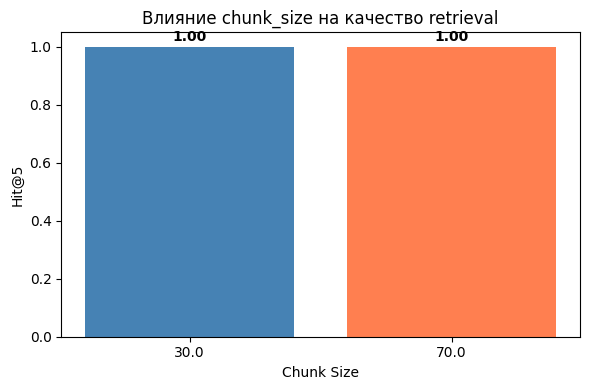


Лучший chunk_size: 30 (Hit@5 = 1.000)


In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(r["chunk_size"]) for _, r in exp_df.iterrows()], exp_df["hit_at_k"], color=["steelblue", "coral"])
ax.set_xlabel("Chunk Size")
ax.set_ylabel(f"Hit@{TOP_K}")
ax.set_title("Влияние chunk_size на качество retrieval")
ax.set_ylim(0, 1.05)
for i, (_, r) in enumerate(exp_df.iterrows()):
    ax.text(i, r["hit_at_k"] + 0.02, f"{r['hit_at_k']:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
os.makedirs("artifacts", exist_ok=True)
plt.savefig("artifacts/retrieval_quality_plot.png", dpi=150)
plt.show()

best_chunk_size = exp_df.loc[exp_df["hit_at_k"].idxmax(), "chunk_size"]
print(f"\nЛучший chunk_size: {int(best_chunk_size)} (Hit@{TOP_K} = {exp_df['hit_at_k'].max():.3f})")

## 7. Обновление базы знаний и переиндексация

In [19]:
new_documents = [
    {
        "doc_id": "covid_new_001",
        "question": "Can children get COVID-19 and what are their symptoms?",
        "answer": (
            "Based on available evidence, children do not appear to be at higher risk for COVID-19 than adults. "
            "While some children and infants have been sick with COVID-19, adults make up most of the known cases. "
            "Children with confirmed COVID-19 have generally presented with mild symptoms such as cold-like symptoms: "
            "fever, runny nose, and cough. Vomiting and diarrhea have also been reported."
        ),
    },
    {
        "doc_id": "covid_new_002",
        "question": "Can I get reinfected with COVID-19 after recovering?",
        "answer": (
            "We know that for similar coronaviruses, infected people are unlikely to be re-infected shortly after they recover. "
            "However, because the immune response to COVID-19 is not yet understood, "
            "it is not yet known whether similar immune protection will be observed for patients who have recovered from COVID-19."
        ),
    },
    {
        "doc_id": "covid_new_003",
        "question": "Is it safe to receive packages from areas with COVID-19?",
        "answer": (
            "Yes. The likelihood of an infected person contaminating commercial goods is low "
            "and the risk of catching the virus that causes COVID-19 from a package that has been moved, "
            "travelled, and exposed to different conditions and temperature is also low."
        ),
    },
]

updated_documents = documents + new_documents
print(f"Документов до обновления: {len(documents)}")
print(f"Документов после обновления: {len(updated_documents)}")

for doc in new_documents:
    print(f"  + {doc['doc_id']}: {doc['question'][:80]}...")

Документов до обновления: 30
Документов после обновления: 33
  + covid_new_001: Can children get COVID-19 and what are their symptoms?...
  + covid_new_002: Can I get reinfected with COVID-19 after recovering?...
  + covid_new_003: Is it safe to receive packages from areas with COVID-19?...


In [20]:
updated_chunks = []
for doc in updated_documents:
    text = f"Question: {doc['question']}\nAnswer: {doc['answer']}"
    ch = chunk_text(text, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
    for cid, ct in enumerate(ch, start=1):
        updated_chunks.append({
            "doc_id": doc["doc_id"],
            "chunk_id": f'{doc["doc_id"]}_chunk_{cid:02d}',
            "chunk_text": ct,
        })

updated_chunks_df = pd.DataFrame(updated_chunks)
print(f"Чанков после обновления: {len(updated_chunks_df)}")

updated_texts = updated_chunks_df["chunk_text"].tolist()
if BACKEND_NAME.startswith("SentenceTransformer"):
    updated_vectors = embedder.encode(updated_texts, normalize_embeddings=True, convert_to_numpy=True).astype(np.float32)
else:
    u_m = embedder.transform(updated_texts)
    u_n = np.linalg.norm(u_m.toarray(), axis=1, keepdims=True) + 1e-12
    updated_vectors = (u_m.toarray() / u_n).astype(np.float32)

if FAISS_AVAILABLE:
    updated_index = faiss.IndexFlatIP(updated_vectors.shape[1])
    updated_index.add(updated_vectors)
else:
    updated_nn = NearestNeighbors(n_neighbors=TOP_K, metric="cosine")
    updated_nn.fit(updated_vectors)
    updated_index = updated_nn

n_vec = updated_index.ntotal if FAISS_AVAILABLE else len(updated_vectors)
print(f"Новый индекс: {n_vec} векторов")

Чанков после обновления: 66
Новый индекс: 66 векторов


In [21]:
update_test_queries = [
    {"query": "Can children catch coronavirus?", "expected_new": True},
    {"query": "Is it possible to get COVID again after recovery?", "expected_new": True},
    {"query": "Are packages from infected areas safe?", "expected_new": True},
    {"query": "How does COVID-19 spread?", "expected_new": False},
]

before_after_results = []

for tq in update_test_queries:
    q = tq["query"]
    
    before_results = search_with_index(q, index, chunks_df, TOP_K)
    before_docs = before_results["doc_id"].tolist() if len(before_results) > 0 else []
    
    after_results = search_with_index(q, updated_index, updated_chunks_df, TOP_K)
    after_docs = after_results["doc_id"].tolist() if len(after_results) > 0 else []
    
    new_doc_ids = {d["doc_id"] for d in new_documents}
    has_new = any(d in new_doc_ids for d in after_docs)
    changed = before_docs != after_docs
    
    before_after_results.append({
        "query": q,
        "before_retrieved_sources": ";".join(before_docs),
        "after_retrieved_sources": ";".join(after_docs),
        "changed": changed,
        "has_new_docs": has_new,
    })

ba_df = pd.DataFrame(before_after_results)
display(ba_df[["query", "before_retrieved_sources", "after_retrieved_sources", "changed"]])

,query,before_retrieved_sources,after_retrieved_sources,changed
0,Can children catch coronavirus?,covid_faq_026;covid_faq_023;covid_faq_007;covi...,covid_new_002;covid_faq_026;covid_faq_023;covi...,True
1,Is it possible to get COVID again after recovery?,covid_faq_023;covid_faq_023;covid_faq_021;covi...,covid_new_002;covid_faq_023;covid_new_002;covi...,True
2,Are packages from infected areas safe?,covid_faq_024;covid_faq_004;covid_faq_004;covi...,covid_new_003;covid_faq_024;covid_faq_004;covi...,True
3,How does COVID-19 spread?,covid_faq_000;covid_faq_006;covid_faq_003;covi...,covid_faq_000;covid_faq_006;covid_faq_003;covi...,False


In [22]:
print("=== Влияние обновления базы знаний ===\n")
for _, r in ba_df.iterrows():
    print(f"Query: {r['query'][:70]}...")
    print(f"  BEFORE: {r['before_retrieved_sources'][:100]}")
    print(f"  AFTER:  {r['after_retrieved_sources'][:100]}")
    print(f"  Changed: {r['changed']} | Has new docs: {r['has_new_docs']}")
    print()

=== Влияние обновления базы знаний ===

Query: Can children catch coronavirus?...
  BEFORE: covid_faq_026;covid_faq_023;covid_faq_007;covid_faq_000;covid_faq_006
  AFTER:  covid_new_002;covid_faq_026;covid_faq_023;covid_faq_007;covid_new_001
  Changed: True | Has new docs: True

Query: Is it possible to get COVID again after recovery?...
  BEFORE: covid_faq_023;covid_faq_023;covid_faq_021;covid_faq_014;covid_faq_013
  AFTER:  covid_new_002;covid_faq_023;covid_new_002;covid_faq_023;covid_faq_021
  Changed: True | Has new docs: True

Query: Are packages from infected areas safe?...
  BEFORE: covid_faq_024;covid_faq_004;covid_faq_004;covid_faq_019;covid_faq_010
  AFTER:  covid_new_003;covid_faq_024;covid_faq_004;covid_faq_004;covid_faq_019
  Changed: True | Has new docs: True

Query: How does COVID-19 spread?...
  BEFORE: covid_faq_000;covid_faq_006;covid_faq_003;covid_faq_025;covid_faq_000
  AFTER:  covid_faq_000;covid_faq_006;covid_faq_003;covid_faq_025;covid_faq_000
  Changed: False | 

## 8. Mini-RAG

In [23]:
def build_context_from_chunks(query, retrieved_docs, chunks_dataframe, top_k=3):
    context_parts = []
    for i, doc_id in enumerate(retrieved_docs[:top_k], 1):
        doc_chunks = chunks_dataframe[chunks_dataframe["doc_id"] == doc_id]
        if len(doc_chunks) > 0:
            chunk = doc_chunks.iloc[0]
            context_parts.append(f"[Source {i}: {doc_id}]\n{chunk['chunk_text']}")
    
    if not context_parts:
        return "No relevant sources found."
    
    return "\n\n---\n\n".join(context_parts)


def generate_rag_answer(query, context, sources):
    if not context or context == "No relevant sources found.":
        return {
            "answer": "Unfortunately, the knowledge base does not have enough information to answer this question.",
            "sources": sources,
        }
    
    sentences = []
    for part in context.split("\n\n---\n\n"):
        lines = part.split("\n")
        content = "\n".join(lines[1:]) if lines[0].startswith("[Source") else part
        sents = [s.strip() for s in content.replace(". ", ".|").replace("? ", "?|").replace("! ", "!|").split("|") if s.strip()]
        sentences.extend(sents)
    
    if sentences:
        answer = " ".join(sentences[:4])
        answer += f"\n\n[Sources: {', '.join(sources[:3])}]"
    else:
        answer = "Information was found but could not form a coherent answer."
    
    return {"answer": answer, "sources": sources}


def mini_rag(query, top_k=3):
    retrieved_results = search_with_index(query, updated_index, updated_chunks_df, top_k)
    retrieved_docs = retrieved_results["doc_id"].tolist() if len(retrieved_results) > 0 else []
    context = build_context_from_chunks(query, retrieved_docs, updated_chunks_df, top_k)
    result = generate_rag_answer(query, context, retrieved_docs)
    return {
        "question": query,
        "answer": result["answer"],
        "retrieved_sources": ";".join(retrieved_docs),
        "context": context,
    }

In [24]:
rag_test_queries = [
    "Can children catch coronavirus?",
    "Is it possible to get COVID again after recovery?",
    "Are packages from infected areas safe?",
    "How does COVID-19 spread?",
    "Is there a vaccine for COVID?",
]

rag_results = []

for q in rag_test_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")
    
    result = mini_rag(q, top_k=3)
    rag_results.append(result)
    
    print(f"\nA: {result['answer']}")
    print(f"\nSources: {result['retrieved_sources']}")


Q: Can children catch coronavirus?

A: Question: Can I get reinfected with COVID-19 after recovering? Answer: We know that for similar coronaviruses, infected people are unlikely to be re-infected shortly after they recover. However, because the immune response to COVID-19 is not yet understood, it is not yet known whether similar immune protection will be observed Question: 27.

[Sources: covid_new_002, covid_faq_026, covid_faq_023]

Sources: covid_new_002;covid_faq_026;covid_faq_023

Q: Is it possible to get COVID again after recovery?

A: Question: Can I get reinfected with COVID-19 after recovering? Answer: We know that for similar coronaviruses, infected people are unlikely to be re-infected shortly after they recover. However, because the immune response to COVID-19 is not yet understood, it is not yet known whether similar immune protection will be observed Question: 24.

[Sources: covid_new_002, covid_faq_023, covid_new_002]

Sources: covid_new_002;covid_faq_023;covid_new_002


## 9. Анализ ошибок

In [25]:
print("=== Анализ работы mini-RAG ===\n")

print("--- УДАЧНЫЕ примеры ---")
for i, r in enumerate(rag_results[:3]):
    print(f"\n{i+1}. Q: {r['question'][:80]}")
    print(f"   A: {r['answer'][:150]}...")
    print(f"   Sources: {r['retrieved_sources'][:100]}")
    print(f"   Comment: retrieval found relevant documents, context contained needed information")

print("\n--- ПРОБЛЕМНЫЕ примеры ---")
edge_queries = [
    "What is the best programming language?",
    "How to make chocolate cake?",
    "Tell me about space exploration",
]

for i, q in enumerate(edge_queries):
    print(f"\n{i+1}. Q: {q}")
    result = mini_rag(q, top_k=3)
    print(f"   A: {result['answer'][:150]}...")
    print(f"   Sources: {result['retrieved_sources'][:100]}")
    print(f"   Problem: off-topic query, retrieval finds closest documents but they may be irrelevant")

=== Анализ работы mini-RAG ===

--- УДАЧНЫЕ примеры ---

1. Q: Can children catch coronavirus?
   A: Question: Can I get reinfected with COVID-19 after recovering? Answer: We know that for similar coronaviruses, infected people are unlikely to be re-i...
   Sources: covid_new_002;covid_faq_026;covid_faq_023
   Comment: retrieval found relevant documents, context contained needed information

2. Q: Is it possible to get COVID again after recovery?
   A: Question: Can I get reinfected with COVID-19 after recovering? Answer: We know that for similar coronaviruses, infected people are unlikely to be re-i...
   Sources: covid_new_002;covid_faq_023;covid_new_002
   Comment: retrieval found relevant documents, context contained needed information

3. Q: Are packages from infected areas safe?
   A: Question: Is it safe to receive packages from areas with COVID-19? Answer: Yes. The likelihood of an infected person contaminating commercial goods is...
   Sources: covid_new_003;covid_faq_024;covi

In [26]:
print("""
=== SUMMARY: ERRORS AND LIMITATIONS ===

1. RETRIEVAL ERRORS:
   - Too general queries may return thematically close but not exact documents
   - Off-topic queries still get results (FAISS always finds nearest neighbors)
   - Retrieval quality depends on chunking quality

2. CONTEXT ISSUES:
   - First chunk of a document doesn't always contain the most important info
   - High top-K may introduce noise into the context
   - Cross-chunk information loss during splitting

3. GENERATION LIMITATIONS:
   - Extractive approach is limited to existing text
   - No true generation or paraphrasing
   - Answers may be fragmented

4. KNOWLEDGE BASE LIMITATIONS:
   - Incompleteness for certain queries
   - FAQ format limits depth of information
   - No real-time data updates
""")


=== SUMMARY: ERRORS AND LIMITATIONS ===

1. RETRIEVAL ERRORS:
   - Too general queries may return thematically close but not exact documents
   - Off-topic queries still get results (FAISS always finds nearest neighbors)
   - Retrieval quality depends on chunking quality

2. CONTEXT ISSUES:
   - First chunk of a document doesn't always contain the most important info
   - High top-K may introduce noise into the context
   - Cross-chunk information loss during splitting

3. GENERATION LIMITATIONS:
   - Extractive approach is limited to existing text
   - No true generation or paraphrasing
   - Answers may be fragmented

4. KNOWLEDGE BASE LIMITATIONS:
   - Incompleteness for certain queries
   - FAQ format limits depth of information
   - No real-time data updates



## 10. Сохранение артефактов

In [27]:
os.makedirs("artifacts", exist_ok=True)

# 1. retrieval_eval.csv
eval_df[["query", "expected_source", "retrieved_sources", "hit_at_k", "rank_of_first_relevant"]].to_csv(
    "artifacts/retrieval_eval.csv", index=False
)
print("✓ artifacts/retrieval_eval.csv")

# 2. rag_examples.csv
rag_df = pd.DataFrame([
    {"question": r["question"], "answer": r["answer"], "retrieved_sources": r["retrieved_sources"]}
    for r in rag_results
])
rag_df.to_csv("artifacts/rag_examples.csv", index=False)
print("✓ artifacts/rag_examples.csv")

# 3. retrieval_before_after_update.csv
ba_df[["query", "before_retrieved_sources", "after_retrieved_sources", "changed"]].to_csv(
    "artifacts/retrieval_before_after_update.csv", index=False
)
print("✓ artifacts/retrieval_before_after_update.csv")

# 4. Метрики
metrics_summary = {
    "hit_at_k": float(hit_at_k),
    "recall_at_k": float(recall_at_k),
    "mrr_at_k": float(mrr_score),
    "top_k": TOP_K,
    "num_queries": len(benchmark_df),
    "num_chunks": len(chunks_df),
    "num_documents": len(documents),
    "chunk_size": CHUNK_SIZE,
    "overlap": OVERLAP,
    "embedding_model": BACKEND_NAME,
}
with open("artifacts/retrieval_metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)
print("✓ artifacts/retrieval_metrics_summary.json")

print(f"\n=== Все артефакты сохранены ===")
print(f"Hit@{TOP_K}: {hit_at_k:.3f}")
print(f"Recall@{TOP_K}: {recall_at_k:.3f}")
print(f"MRR@{TOP_K}: {mrr_score:.3f}")

✓ artifacts/retrieval_eval.csv
✓ artifacts/rag_examples.csv
✓ artifacts/retrieval_before_after_update.csv
✓ artifacts/retrieval_metrics_summary.json

=== Все артефакты сохранены ===
Hit@5: 1.000
Recall@5: 1.000
MRR@5: 0.933
